In [37]:
MODEL_FILE = 'reactions.tsv'
MEASURED_MID = 'measured_MID.tsv'
MEASURED_FLUX = 'measured_fluxes.tsv'
INITIAL_FLUX = 'fluxes.tsv'
from freeflux import Model

model = Model("simple_model")
model.read_from_file(MODEL_FILE)

In [38]:
model

Model simple_model (6 metabolites, 6 reactions)
Reaction R1: A->B
Reaction R2: B->D
Reaction R3: D->B
Reaction R4: B->C+E
Reaction R5: B+C->D+E
Reaction R6: D->F

In [39]:
fit = model.fitter('ss')
fit.set_labeling_strategy(
    'A',
    labeling_pattern = ['010'],
    percentage = [1],
    purity = [1]
)

In [40]:
# fit.set_flux_bounds('all', bounds = [0,150])
fit._set_flux_bounds('R1', [100, 100])


In [41]:
fit.set_measured_MDVs_from_file(MEASURED_MID)
fit.set_measured_fluxes_from_file(MEASURED_FLUX)

In [ ]:
fit.prepare(n_jobs = 3)
res = fit.solve(
    solver = 'slsqp',
    ini_fluxes = INITIAL_FLUX)
print(res.optimization_successful)


fitting [elapsed: 0:00:01]
True


In [43]:
print(res.opt_objective)
print(res.opt_total_fluxes)

87.837
R1: 100.0
R2: 80.544
R3: 0.001
R4: 9.728
R5: 9.728
R6: 90.272


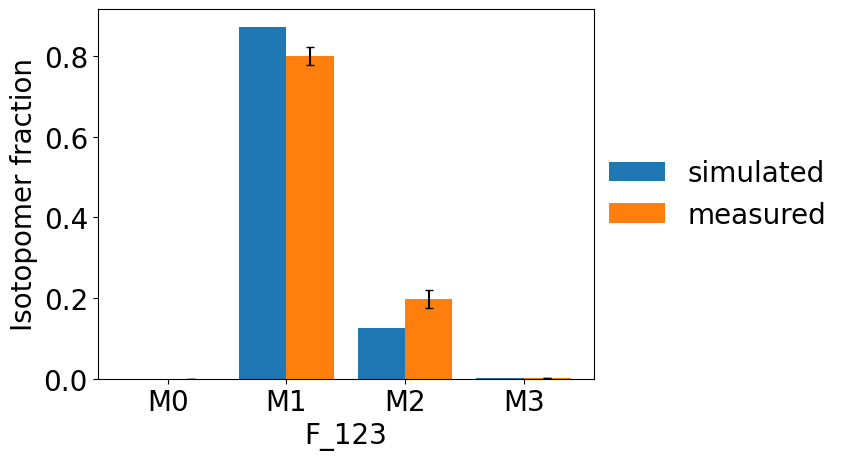

In [44]:
res.plot_simulated_vs_measured_MDVs(show_fig = True, output_dir = None)


In [45]:
print(res.estimate_confidence_intervals(
    which = 'net',
    confidence_level = 0.95
))

R1: [99.752, 100.248]
R2: [0.0, 3558161.534]
R3: [0.0, 3772265.217]
R4: [0.0, 107101.841]
R5: [0.0, 107101.841]
R6: [0.0, 107182.385]
